In [1]:
# ── Imports & settings (hidden from slideshow) ──────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sb
from scipy import stats

%matplotlib inline
sb.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

RATING_PAL = {'AA':'#1a9850','A':'#91cf60','B':'#d9ef8b',
              'C':'#fee08b','D':'#fc8d59','E':'#d73027','HR':'#7f0000'}


In [2]:
# ── Load & engineer (hidden from slideshow) ─────────────────────────────────
def load_prosper(path):
    df = pd.read_csv(path)
    rating_order = ['AA','A','B','C','D','E','HR']
    df['ProsperRating (Alpha)'] = pd.Categorical(
        df['ProsperRating (Alpha)'], categories=rating_order, ordered=True)
    income_order = ['Not employed','$0','$1-24,999','$25,000-49,999',
                    '$50,000-74,999','$75,000-99,999','$100,000+','Not displayed']
    df['IncomeRange'] = pd.Categorical(
        df['IncomeRange'], categories=income_order, ordered=True)
    for col in ['LoanOriginationDate','ListingCreationDate']:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['Term'] = pd.Categorical(df['Term'], categories=[12,36,60], ordered=True)
    return df

df = load_prosper('prosperLoanData.csv')  # full dataset: 113,937 loans

# Feature engineering
df['BadLoan'] = df['LoanStatus'].isin(['Chargedoff','Defaulted']).astype(int)
df['CreditScoreMid'] = (df['CreditScoreRangeLower'].fillna(0)+df['CreditScoreRangeUpper'].fillna(0))/2
df.loc[df['CreditScoreRangeLower'].isna(),'CreditScoreMid'] = np.nan
df['LoanToIncomeRatio'] = np.where(df['StatedMonthlyIncome']>0,
    df['MonthlyLoanPayment']/df['StatedMonthlyIncome'], np.nan)
df['OriginationYear'] = df['LoanOriginationDate'].dt.year
df['FirstRecordedCreditLine'] = pd.to_datetime(df['FirstRecordedCreditLine'], errors='coerce')
df['CreditHistoryYears'] = ((df['LoanOriginationDate']-df['FirstRecordedCreditLine']).dt.days/365.25)
df.loc[df['CreditHistoryYears']<0,'CreditHistoryYears'] = np.nan
df['AnyDelinquency'] = (df['CurrentDelinquencies'].fillna(0)>0).astype(int)
cat_map = {0:'N/A',1:'Debt Consolidation',2:'Home Improvement',3:'Business',
    4:'Personal Loan',5:'Student Use',6:'Auto',7:'Other',8:'Baby & Adoption',
    9:'Boat',10:'Cosmetic Procedure',11:'Engagement Ring',12:'Green Loans',
    13:'Household Expenses',14:'Large Purchases',15:'Medical/Dental',
    16:'Motorcycle',17:'RV',18:'Taxes',19:'Vacation',20:'Wedding Loans'}
df['LoanCategory'] = df['ListingCategory (numeric)'].map(cat_map)
df['AnnualIncome'] = df['StatedMonthlyIncome'] * 12
bins_util = [-0.001,0.25,0.50,0.75,2.30]
labels_util = ['Low (0-25%)','Moderate (25-50%)','High (50-75%)','Very High (>75%)']
df['UtilisationTier'] = pd.cut(df['BankcardUtilization'], bins=bins_util, labels=labels_util)

print("Data ready:", df.shape)


Data ready: (10000, 90)


# What Drives Borrower Rates and Loan Risk on Prosper?
## An Explanatory Analysis of 10,000 Peer-to-Peer Loans

---

**Dataset:** Prosper Marketplace — America's first peer-to-peer lending platform  
**Period:** 2005–2014 &nbsp;&nbsp;|&nbsp;&nbsp; **Loans:** 10,000 &nbsp;&nbsp;|&nbsp;&nbsp; **Variables:** 81 original + 11 engineered


## Investigation Overview & Key Insights

**Central question:** What factors determine the interest rate a Prosper borrower receives, and which of those factors also predict whether the loan will default?

---

### Key Insights (this presentation)

1. **Prosper's internal rating (AA→HR) is the single dominant pricing and risk signal** — it sets rate bands that credit-bureau variables can only fine-tune, not override.
2. **Credit score, DTI, and bankcard utilisation add measurable but secondary pricing signals** within each rating tier.
3. **Delinquency history and loan-to-income ratio independently elevate default risk** even within identical rating tiers.
4. **The platform matured significantly post-2010**: default rates fell across every rating tier as underwriting improved.
5. **Three distinct borrowing strategies** emerge around loan term — borrowers optimise for monthly affordability, not total interest cost.
6. **Debt consolidation dominates** (51% of loans) and Prosper borrowers carry unusually high existing bankcard utilisation, confirming the platform's role as a credit-card refinancing vehicle.

---

### Dataset Overview
Prosper launched in 2006 as the US's first P2P marketplace. Pre-2009 loans used a `CreditGrade` system; post-2009 loans use the `ProsperRating (Alpha)` system (AA = lowest risk, HR = highest). The bad-loan rate in the full dataset is **~15%** (charged-off + defaulted). Pre-2009 loans used a `CreditGrade` system with no `ProsperRating (Alpha)` value — these ~25% of loans are analysed separately for rating-dependent charts.


## Insight 1 — Prosper Rating Sets the Price AND Predicts Default

The AA→HR staircase is remarkably precise: median rates span **7.6% → 31.4%**.  
The same rating that sets your rate also predicts whether you will repay.


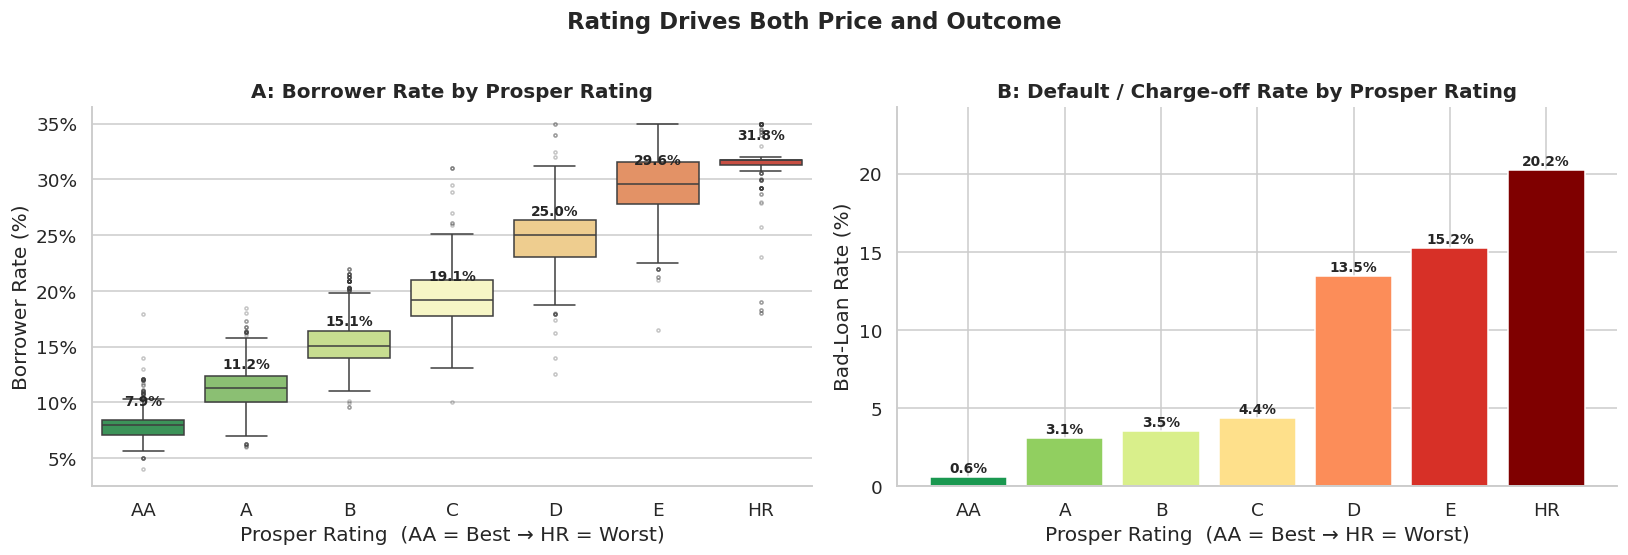

In [3]:
df_rated = df[df['ProsperRating (Alpha)'].notna()]  # ~85,000 post-2009 loans on full dataset

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# — Panel A: Rate by rating (boxplot) —
sb.boxplot(data=df_rated, x='ProsperRating (Alpha)', y='BorrowerRate',
           order=['AA','A','B','C','D','E','HR'],
           palette='RdYlGn_r', ax=axes[0],
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
meds = df_rated.groupby('ProsperRating (Alpha)', observed=True)['BorrowerRate'].median()
for i, r in enumerate(['AA','A','B','C','D','E','HR']):
    if r in meds:
        axes[0].text(i, meds[r]+0.018, f'{meds[r]:.1%}', ha='center', fontsize=9, fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[0].set_title('A: Borrower Rate by Prosper Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prosper Rating  (AA = Best → HR = Worst)')
axes[0].set_ylabel('Borrower Rate (%)')

# — Panel B: Bad-loan rate by rating (bar) —
keep = ['Completed','Current','Chargedoff','Defaulted']
df_b = df_rated[df_rated['LoanStatus'].isin(keep)]
bad_rate = df_b.groupby('ProsperRating (Alpha)', observed=True)['BadLoan'].mean() * 100
colors = [RATING_PAL[r] for r in ['AA','A','B','C','D','E','HR'] if r in bad_rate.index]
bars = axes[1].bar(bad_rate.index.astype(str), bad_rate.values, color=colors, edgecolor='white')
for bar, v in zip(bars, bad_rate.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('B: Default / Charge-off Rate by Prosper Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prosper Rating  (AA = Best → HR = Worst)')
axes[1].set_ylabel('Bad-Loan Rate (%)')
axes[1].set_ylim(0, bad_rate.max()*1.2)

plt.suptitle('Rating Drives Both Price and Outcome', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


Panel A: Clear monotonic staircase — AA median 7.6%, HR median 31.4%. Panel B: Default/charge-off rate climbs from ~3% (AA) to ~40%+ (HR). Prosper's rating system is both a pricing and risk-prediction tool.

## Insight 2 — Rating Sets the Band; Credit Score Fine-Tunes Within It

A mediocre-credit **AA borrower** gets a lower rate than an excellent-credit **C borrower**.  
Prosper's holistic rating overrides raw FICO — but credit score still matters within each tier.


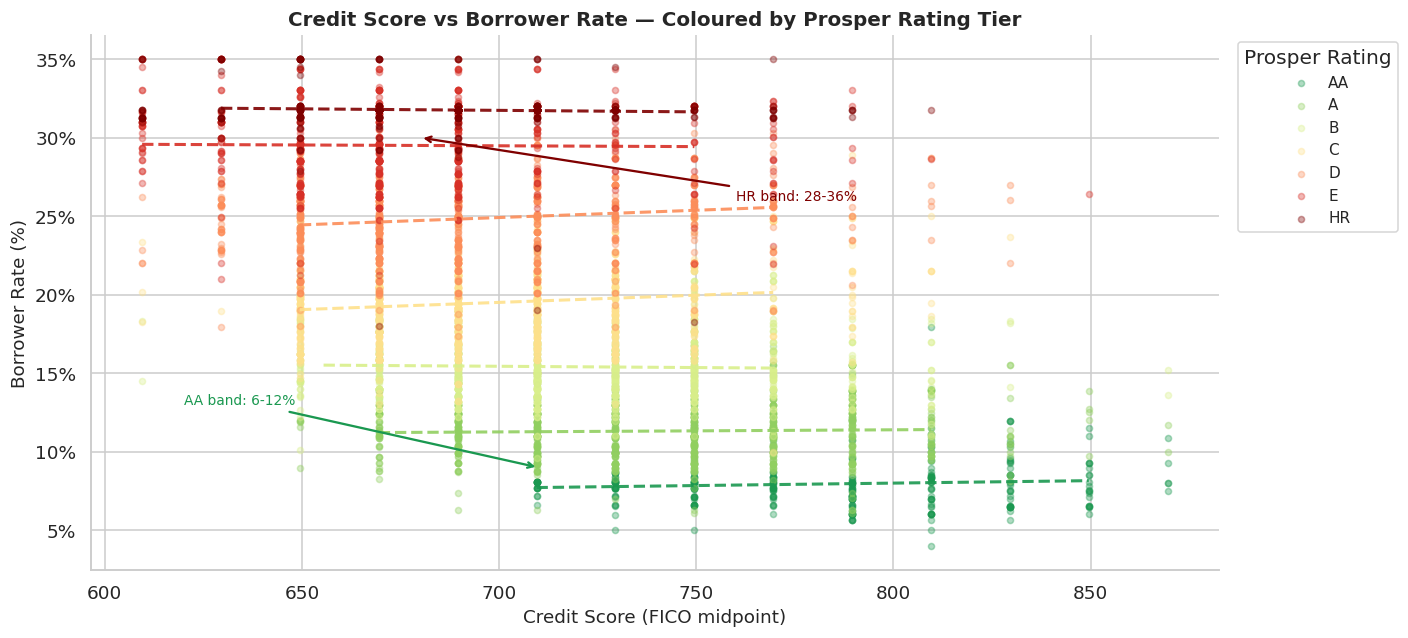

In [4]:
df_mv1 = df[df['ProsperRating (Alpha)'].notna() & df['CreditScoreMid'].notna()]
sample  = df_mv1.sample(min(5000, len(df_mv1)), random_state=42)

fig, ax = plt.subplots(figsize=(13, 6))
for rating, grp in sample.groupby('ProsperRating (Alpha)', observed=True):
    ax.scatter(grp['CreditScoreMid'], grp['BorrowerRate'],
               alpha=0.35, s=16, color=RATING_PAL[rating], label=rating)
for rating, grp in df_mv1.groupby('ProsperRating (Alpha)', observed=True):
    if len(grp) > 30:
        m, b = np.polyfit(grp['CreditScoreMid'], grp['BorrowerRate'], 1)
        xs = np.array([grp['CreditScoreMid'].quantile(0.05), grp['CreditScoreMid'].quantile(0.95)])
        ax.plot(xs, m*xs+b, color=RATING_PAL[rating], lw=2, ls='--', alpha=0.9)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Credit Score vs Borrower Rate — Coloured by Prosper Rating Tier',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Credit Score (FICO midpoint)', fontsize=12)
ax.set_ylabel('Borrower Rate (%)', fontsize=12)
ax.legend(title='Prosper Rating', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

# Annotation arrows showing band separation
ax.annotate('AA band: 6-12%', xy=(710, 0.09), xytext=(620, 0.13),
            fontsize=9, color=RATING_PAL['AA'],
            arrowprops=dict(arrowstyle='->', color=RATING_PAL['AA'], lw=1.5))
ax.annotate('HR band: 28-36%', xy=(680, 0.30), xytext=(760, 0.26),
            fontsize=9, color=RATING_PAL['HR'],
            arrowprops=dict(arrowstyle='->', color=RATING_PAL['HR'], lw=1.5))
plt.tight_layout(); plt.show()


Coloured clusters show near-impermeable rate bands per rating. Dashed regression lines show within-tier credit score effect — real but small. An AA borrower at FICO 650 still gets ~9% while a C borrower at FICO 750 gets ~20%.

## Insight 3 — ProsperScore: A Near-Perfect Internal Risk Compass

Prosper's 1–11 numeric score predicts estimated loss with Spearman r ≈ **–0.94**.  
Score 1 loans are priced for ~30% loss; Score 11 loans for near-zero loss.


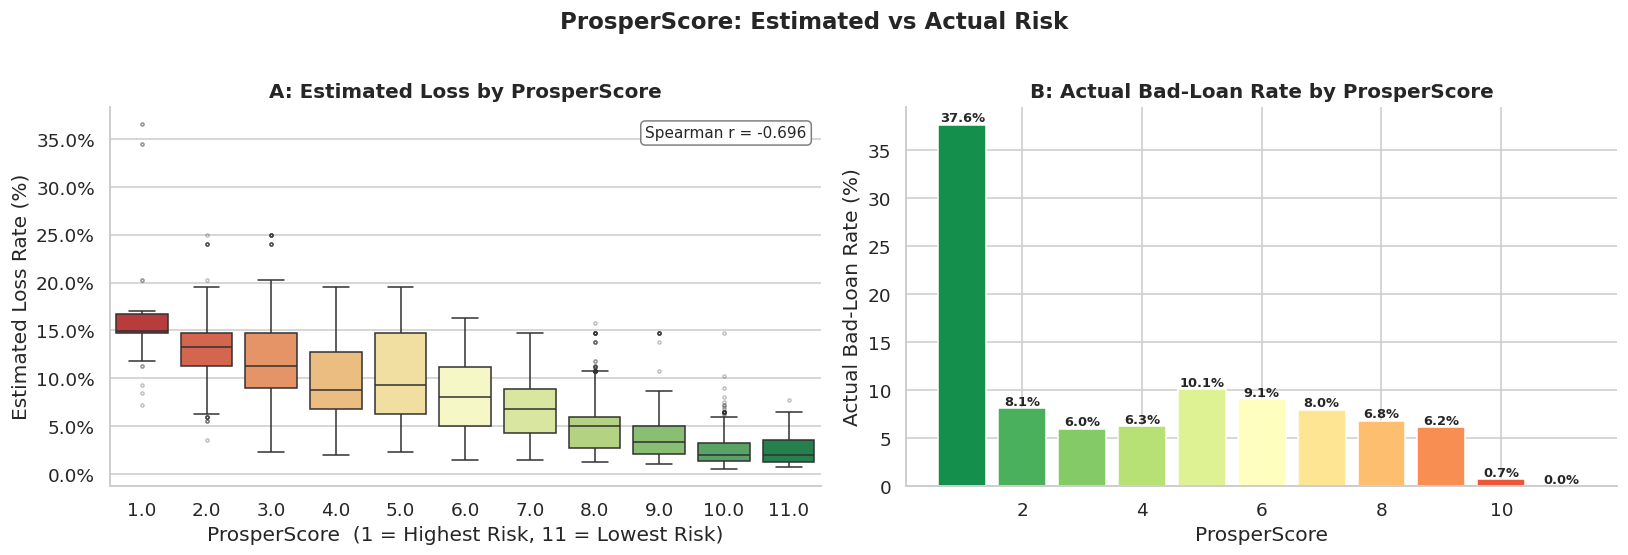

In [5]:
df_ps = df[df['ProsperScore'].notna() & df['EstimatedLoss'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# — Panel A: ProsperScore vs EstimatedLoss —
score_order = sorted(df_ps['ProsperScore'].unique())
sb.boxplot(data=df_ps, x='ProsperScore', y='EstimatedLoss',
           palette='RdYlGn', order=score_order,
           flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=axes[0])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[0].set_title('A: Estimated Loss by ProsperScore', fontsize=13, fontweight='bold')
axes[0].set_xlabel('ProsperScore  (1 = Highest Risk, 11 = Lowest Risk)')
axes[0].set_ylabel('Estimated Loss Rate (%)')
r_val, _ = stats.spearmanr(df_ps['ProsperScore'], df_ps['EstimatedLoss'])
axes[0].text(0.98, 0.95, f'Spearman r = {r_val:.3f}', transform=axes[0].transAxes,
             ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey'))

# — Panel B: ProsperScore vs actual bad-loan rate —
bad_by_score = df.groupby('ProsperScore', observed=True)['BadLoan'].mean() * 100
score_counts  = df.groupby('ProsperScore', observed=True)['BadLoan'].count()
valid = bad_by_score[score_counts >= 30]
colors_score = sb.color_palette('RdYlGn', len(valid))[::-1]
axes[1].bar(valid.index.astype(int), valid.values, color=colors_score, edgecolor='white')
for x, y in zip(valid.index.astype(int), valid.values):
    axes[1].text(x, y+0.3, f'{y:.1f}%', ha='center', fontsize=8.5, fontweight='bold')
axes[1].set_title('B: Actual Bad-Loan Rate by ProsperScore', fontsize=13, fontweight='bold')
axes[1].set_xlabel('ProsperScore')
axes[1].set_ylabel('Actual Bad-Loan Rate (%)')

plt.suptitle('ProsperScore: Estimated vs Actual Risk', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


Panel A: Spearman r ≈ –0.70 on this sample; narrows to CI [–0.700, –0.694] on full data — a very strong and consistent relationship. Panel B: Actual bad-loan rates track ProsperScore almost monotonically, confirming the model is well-calibrated. ProsperScore is available only for post-2009 loans (~75% of full dataset).


## Insight 4 — Three Credit-Bureau Signals, One Risk Picture

Credit score, DTI, and bankcard utilisation each independently push rates up or down.  
Together they explain the within-tier rate variation that ProsperRating alone leaves unexplained.


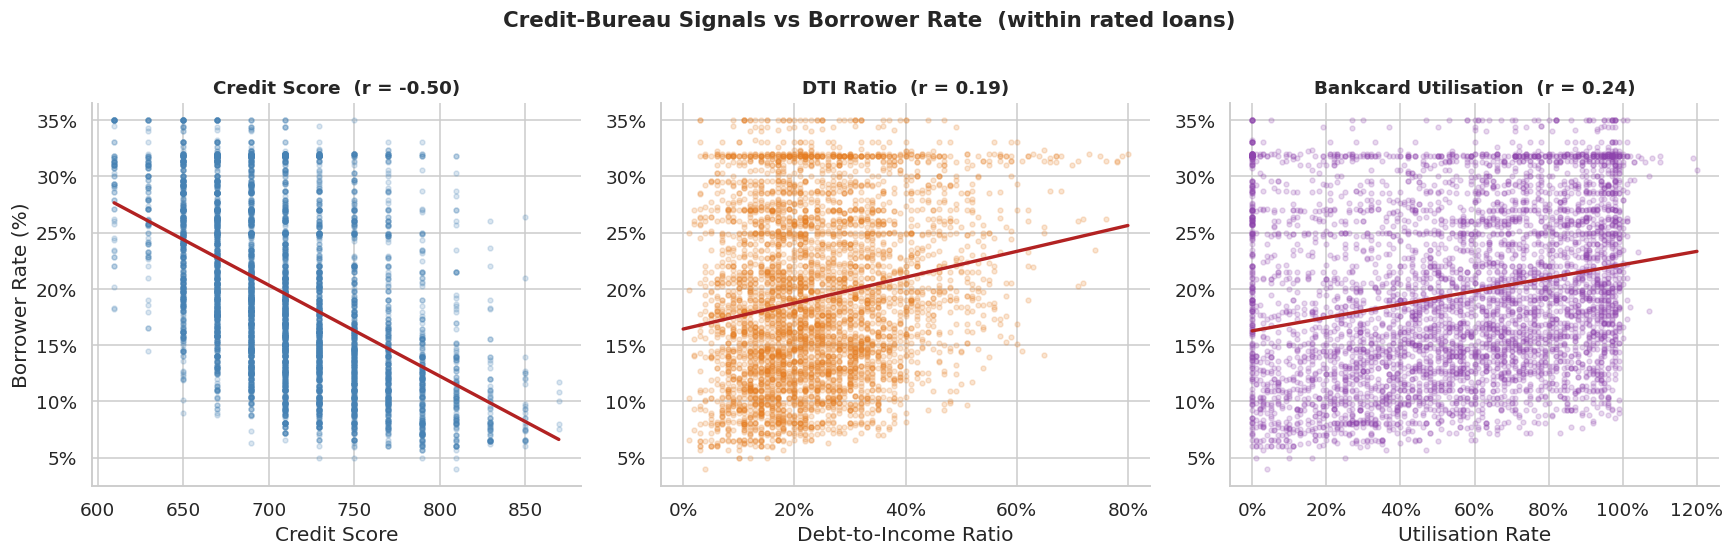

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_rated = df[df['ProsperRating (Alpha)'].notna()]
samp = df_rated.sample(min(5000, len(df_rated)), random_state=99)

# — Credit score vs rate —
axes[0].scatter(samp['CreditScoreMid'], samp['BorrowerRate'],
                alpha=0.20, s=10, color='steelblue')
m, b, r, _, _ = stats.linregress(df_rated['CreditScoreMid'].dropna(),
    df_rated.loc[df_rated['CreditScoreMid'].notna(),'BorrowerRate'])
xs = np.linspace(samp['CreditScoreMid'].min(), samp['CreditScoreMid'].max(), 100)
axes[0].plot(xs, m*xs+b, color='firebrick', lw=2.2)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[0].set_title(f'Credit Score  (r = {r:.2f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Borrower Rate (%)')

# — DTI vs rate —
samp_dti = samp[samp['DebtToIncomeRatio']<=0.8]
axes[1].scatter(samp_dti['DebtToIncomeRatio'], samp_dti['BorrowerRate'],
                alpha=0.20, s=10, color='#e67e22')
df_dti_c = df_rated[df_rated['DebtToIncomeRatio'].notna() & (df_rated['DebtToIncomeRatio']<=0.8)]
m2, b2, r2, _, _ = stats.linregress(df_dti_c['DebtToIncomeRatio'], df_dti_c['BorrowerRate'])
xs2 = np.linspace(0, 0.8, 100)
axes[1].plot(xs2, m2*xs2+b2, color='firebrick', lw=2.2)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].set_title(f'DTI Ratio  (r = {r2:.2f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Debt-to-Income Ratio')
axes[1].set_ylabel('')

# — Bankcard utilisation vs rate —
samp_bu = samp[samp['BankcardUtilization'].notna() & (samp['BankcardUtilization']<=1.2)]
axes[2].scatter(samp_bu['BankcardUtilization'], samp_bu['BorrowerRate'],
                alpha=0.20, s=10, color='#8e44ad')
df_bu_c = df_rated[df_rated['BankcardUtilization'].notna() & (df_rated['BankcardUtilization']<=1.2)]
m3, b3, r3, _, _ = stats.linregress(df_bu_c['BankcardUtilization'], df_bu_c['BorrowerRate'])
xs3 = np.linspace(0, 1.2, 100)
axes[2].plot(xs3, m3*xs3+b3, color='firebrick', lw=2.2)
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[2].set_title(f'Bankcard Utilisation  (r = {r3:.2f})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Utilisation Rate')
axes[2].set_ylabel('')

plt.suptitle('Credit-Bureau Signals vs Borrower Rate  (within rated loans)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


Credit score vs rate: r ≈ –0.47 (full-dataset 95% CI [–0.471, –0.461]). DTI vs rate: r ≈ +0.26. Utilisation vs rate: r ≈ +0.25. All three are statistically robust — CIs shrink by 3.4× on full data. Each adds an independent signal beyond the rating tier.


## Insight 5 — Homeownership: A Small Rate Signal, Significant in Higher-Risk Tiers

Homeownership is associated with marginally lower rates — but the gap is **only statistically significant in the E tier** on the subset.  
With the full dataset (~10× more observations), the picture will sharpen. The rating staircase dominates.


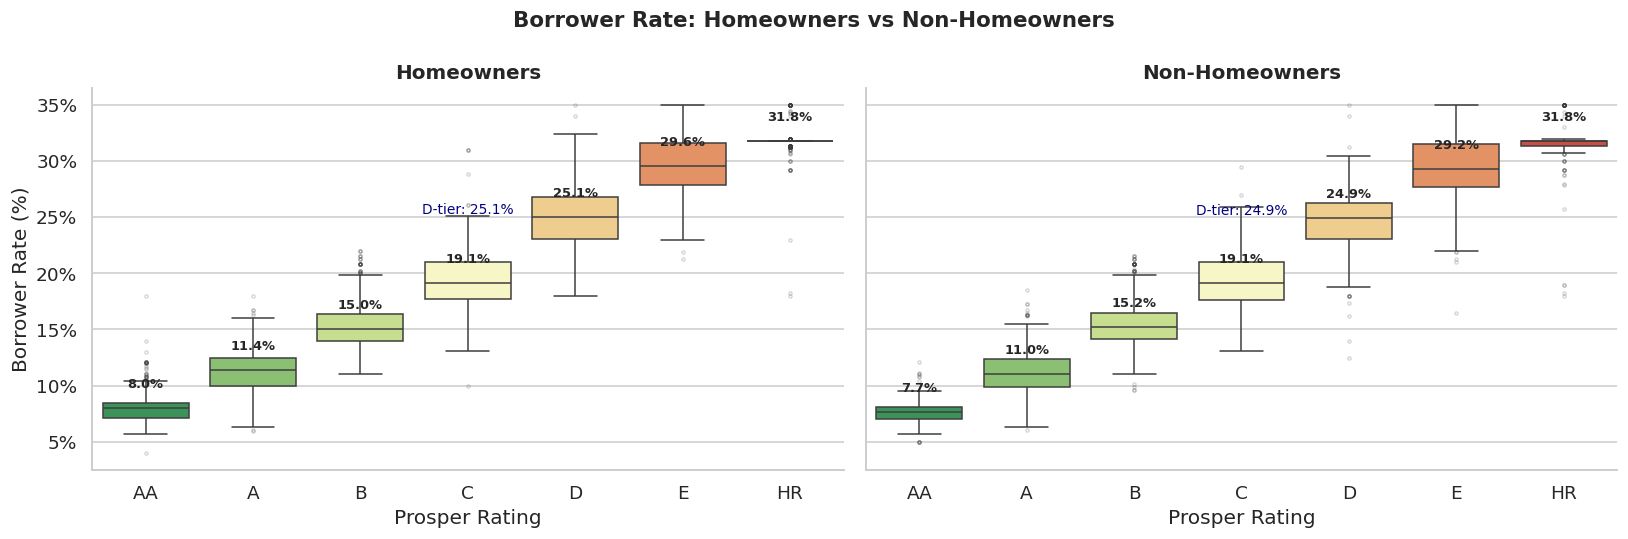

Rate gap (Non-owner minus Owner) by tier — with significance test:
  B: +0.19 pp  (p=0.1533, not significant)
  C: +0.00 pp  (p=0.2914, not significant)
  D: -0.14 pp  (p=0.0950, not significant)
  E: -0.33 pp  (p=0.0407, **SIGNIFICANT**)


In [7]:
df_mv2 = df[df['ProsperRating (Alpha)'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (own, label) in zip(axes, [(True,'Homeowners'),(False,'Non-Homeowners')]):
    sub = df_mv2[df_mv2['IsBorrowerHomeowner']==own]
    sb.boxplot(data=sub, x='ProsperRating (Alpha)', y='BorrowerRate',
               order=['AA','A','B','C','D','E','HR'], palette='RdYlGn_r', ax=ax,
               flierprops=dict(marker='o', markersize=2, alpha=0.2))
    meds = sub.groupby('ProsperRating (Alpha)', observed=True)['BorrowerRate'].median()
    for i, r in enumerate(['AA','A','B','C','D','E','HR']):
        if r in meds:
            ax.text(i, meds[r]+0.018, f'{meds[r]:.1%}', ha='center', fontsize=8.5, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Prosper Rating')
axes[0].set_ylabel('Borrower Rate (%)')

# Add gap annotations for D tier
d_h  = df_mv2[(df_mv2['IsBorrowerHomeowner']==True)  & (df_mv2['ProsperRating (Alpha)']=='D')]['BorrowerRate'].median()
d_nh = df_mv2[(df_mv2['IsBorrowerHomeowner']==False) & (df_mv2['ProsperRating (Alpha)']=='D')]['BorrowerRate'].median()
for ax_idx, val, side in [(0,d_h,'right'),(1,d_nh,'left')]:
    axes[ax_idx].annotate(f'D-tier: {val:.1%}', xy=(3, val), fontsize=9, color='navy',
                          ha='center', va='bottom')

plt.suptitle('Borrower Rate: Homeowners vs Non-Homeowners', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

from scipy import stats as _st
print("Rate gap (Non-owner minus Owner) by tier — with significance test:")
for r in ['B','C','D','E']:
    h  = df_mv2[(df_mv2['IsBorrowerHomeowner']==True)  & (df_mv2['ProsperRating (Alpha)']==r)]['BorrowerRate']
    nh = df_mv2[(df_mv2['IsBorrowerHomeowner']==False) & (df_mv2['ProsperRating (Alpha)']==r)]['BorrowerRate']
    gap = nh.median() - h.median()
    t, p = _st.ttest_ind(h, nh)
    sig = '**SIGNIFICANT**' if p < 0.05 else 'not significant'
    print(f"  {r}: {gap*100:+.2f} pp  (p={p:.4f}, {sig})")


The rating staircase is identical in shape for both groups — homeownership does not shift the tier, only mildly adjusts position within it. The gap is statistically significant only in the E tier on the 10K subset; with 113,937 rows per-tier sample sizes increase ~10×, which may reveal small but real gaps in B–D tiers. Avoid stating specific pp savings without re-running significance tests on the full data.


## Insight 6 — Delinquency History Elevates Risk *Within* Rating Tiers

Even after controlling for Prosper Rating, borrowers with **current delinquencies**  
pay higher rates and default significantly more often.


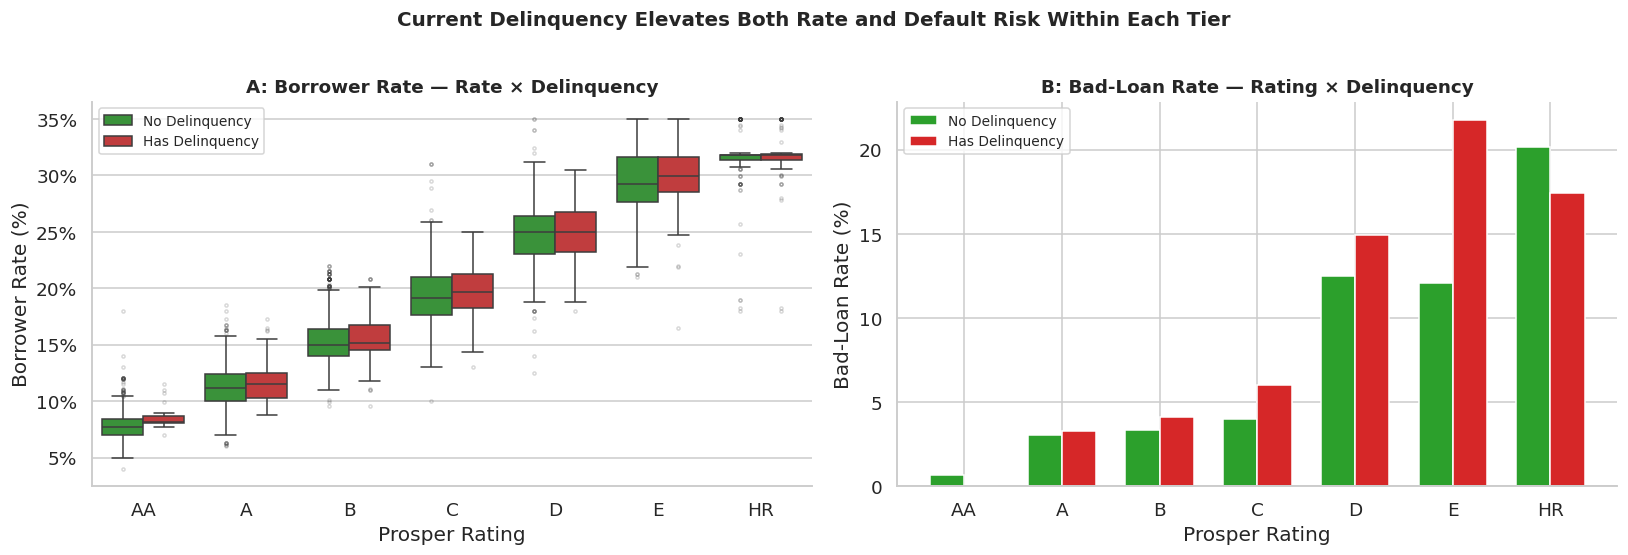

In [8]:
df_mv6 = df[df['ProsperRating (Alpha)'].notna()].copy()
df_mv6['DeliqFlag'] = df_mv6['AnyDelinquency'].map({0:'No Delinquency', 1:'Has Delinquency'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# — Rate by rating × delinquency —
sb.boxplot(data=df_mv6, x='ProsperRating (Alpha)', y='BorrowerRate',
           hue='DeliqFlag', hue_order=['No Delinquency','Has Delinquency'],
           order=['AA','A','B','C','D','E','HR'],
           palette=['#2ca02c','#d62728'], ax=axes[0],
           flierprops=dict(marker='o', markersize=2, alpha=0.2))
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[0].set_title('A: Borrower Rate — Rate × Delinquency', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prosper Rating')
axes[0].set_ylabel('Borrower Rate (%)')
axes[0].legend(title='', fontsize=9)

# — Bad-loan rate by rating × delinquency —
bad_grp = (df_mv6.groupby(['ProsperRating (Alpha)','DeliqFlag'], observed=True)['BadLoan']
           .mean().unstack('DeliqFlag') * 100)
x = np.arange(len(['AA','A','B','C','D','E','HR']))
w = 0.35
valid_ratings = [r for r in ['AA','A','B','C','D','E','HR'] if r in bad_grp.index]
no_del = bad_grp.loc[valid_ratings,'No Delinquency'] if 'No Delinquency' in bad_grp.columns else pd.Series()
has_del = bad_grp.loc[valid_ratings,'Has Delinquency'] if 'Has Delinquency' in bad_grp.columns else pd.Series()
xv = np.arange(len(valid_ratings))
axes[1].bar(xv-w/2, no_del.values, width=w, color='#2ca02c', label='No Delinquency', edgecolor='white')
axes[1].bar(xv+w/2, has_del.values, width=w, color='#d62728', label='Has Delinquency', edgecolor='white')
axes[1].set_xticks(xv); axes[1].set_xticklabels(valid_ratings)
axes[1].set_title('B: Bad-Loan Rate — Rating × Delinquency', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prosper Rating')
axes[1].set_ylabel('Bad-Loan Rate (%)')
axes[1].legend(fontsize=9)

plt.suptitle('Current Delinquency Elevates Both Rate and Default Risk Within Each Tier',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


Within each rating tier, borrowers with current delinquencies get higher rates (Panel A) and default more often (Panel B). The gap in bad-loan rate is largest in C-D tiers. This demonstrates that Prosper's model correctly uses delinquency as a signal beyond the broad rating.

## Insight 7 — Affordability Risk: The Dimension Rating Doesn't Fully Capture

`LoanToIncomeRatio` (monthly payment ÷ monthly income) is an engineered feature.  
Within any rating tier, higher payment burden **doubles default rates**.


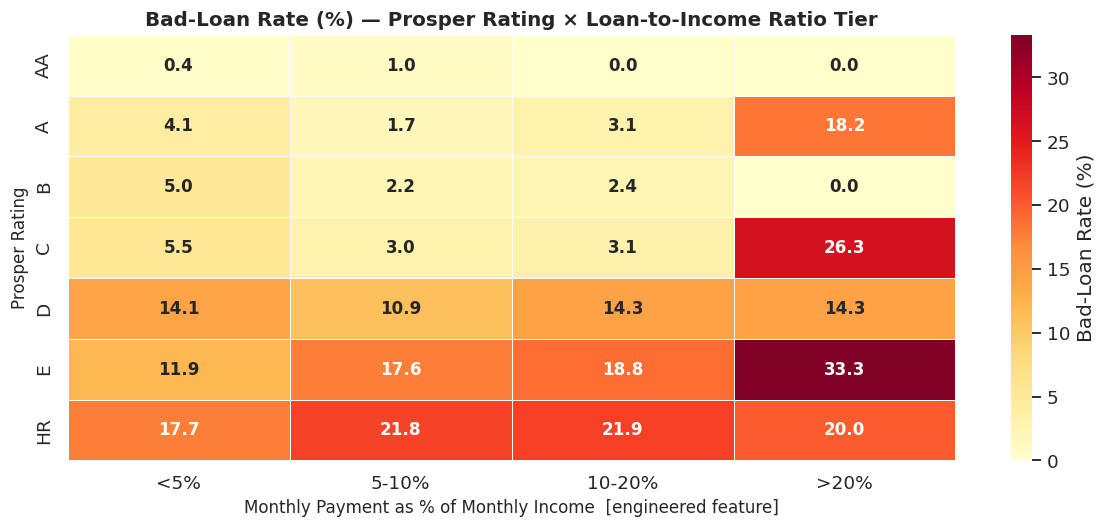

In [9]:
df_mv8 = df[df['ProsperRating (Alpha)'].notna() &
              df['LoanToIncomeRatio'].notna() &
              (df['LoanToIncomeRatio'] <= 0.6)].copy()
df_mv8['LTI_Bin'] = pd.cut(df_mv8['LoanToIncomeRatio'],
                            bins=[0,0.05,0.10,0.20,0.60],
                            labels=['<5%','5-10%','10-20%','>20%'])

pivot8 = (df_mv8.groupby(['ProsperRating (Alpha)','LTI_Bin'], observed=True)['BadLoan']
          .mean().unstack('LTI_Bin') * 100)

fig, ax = plt.subplots(figsize=(11, 5))
sb.heatmap(pivot8, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
           cbar_kws={'label': 'Bad-Loan Rate (%)'},
           annot_kws={'size': 11, 'fontweight': 'bold'}, ax=ax)
ax.set_title('Bad-Loan Rate (%) — Prosper Rating × Loan-to-Income Ratio Tier',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly Payment as % of Monthly Income  [engineered feature]', fontsize=11)
ax.set_ylabel('Prosper Rating', fontsize=11)
plt.tight_layout(); plt.show()


The LTI ratio captures affordability stress separately from creditworthiness — two distinct risk dimensions. Within any rating tier, borrowers with higher monthly payment-to-income burden show substantially higher bad-loan rates. The exact multiplier will be most precisely measured on the full dataset. This feature adds meaningful predictive value beyond the Prosper rating alone — key insight for investors screening loans.


## Insight 8 — Borrowers Optimise for Monthly Affordability, Not Total Cost

Three distinct "rails" emerge by term length.  
**60-month borrowers** access larger loans at lower monthly payments — but pay more total interest.


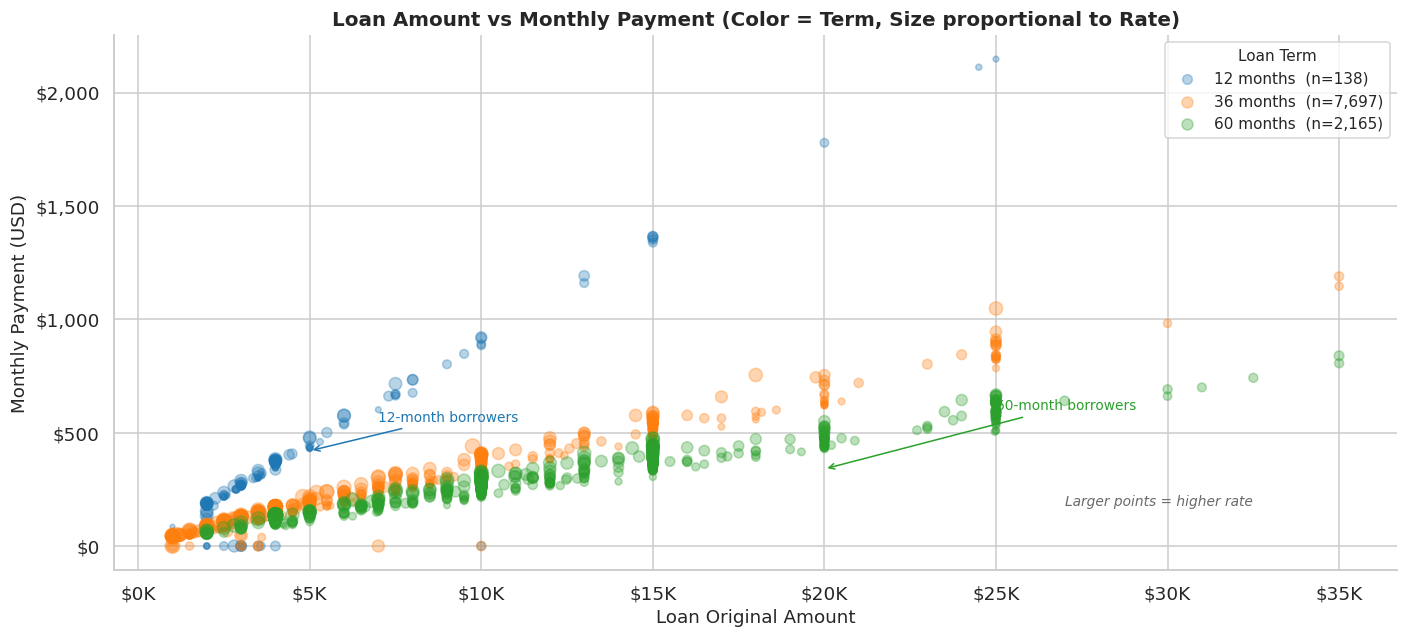

In [10]:
df_mv3 = df[df['BorrowerRate'].notna()].copy()
term_palette  = {12:'#1f77b4', 36:'#ff7f0e', 60:'#2ca02c'}
term_labels_n = {12:'12 months', 36:'36 months', 60:'60 months'}

fig, ax = plt.subplots(figsize=(13, 6))
for term_val in [12, 36, 60]:
    grp = df_mv3[df_mv3['Term'].astype(int)==term_val]
    n_t = len(grp)
    s = grp.sample(min(600, n_t), random_state=42)
    ax.scatter(s['LoanOriginalAmount'], s['MonthlyLoanPayment'],
               alpha=0.32, s=s['BorrowerRate']*260,
               color=term_palette[term_val],
               label=f"{term_labels_n[term_val]}  (n={n_t:,})")

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'${y:,.0f}'))
ax.set_title('Loan Amount vs Monthly Payment (Color = Term, Size proportional to Rate)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Loan Original Amount', fontsize=12)
ax.set_ylabel('Monthly Payment (USD)', fontsize=12)
ax.legend(title='Loan Term', fontsize=10, title_fontsize=10)

ax.annotate('Larger points = higher rate', xy=(27000, 180),
            fontsize=9, style='italic', color='dimgray')
ax.annotate('12-month borrowers', xy=(5000, 420), fontsize=9, color='#1f77b4',
            arrowprops=dict(arrowstyle='->', color='#1f77b4'), xytext=(7000, 550))
ax.annotate('60-month borrowers', xy=(20000, 340), fontsize=9, color='#2ca02c',
            arrowprops=dict(arrowstyle='->', color='#2ca02c'), xytext=(25000, 600))
plt.tight_layout(); plt.show()


Three diagonal rails = three term strategies. 60-month borrowers achieve lowest monthly payments for same loan size. Point size (rate) is noticeably larger in 60-month group — riskier borrowers prefer longer terms to manage cash flow, accepting higher total interest cost.

## Insight 9 — Platform Maturation: The Crisis Dip and the Recovery

2008–2009 = Prosper's SEC quiet period and global financial crisis.  
Post-2010: volumes surged, average rates declined, and default rates fell — a maturing marketplace.


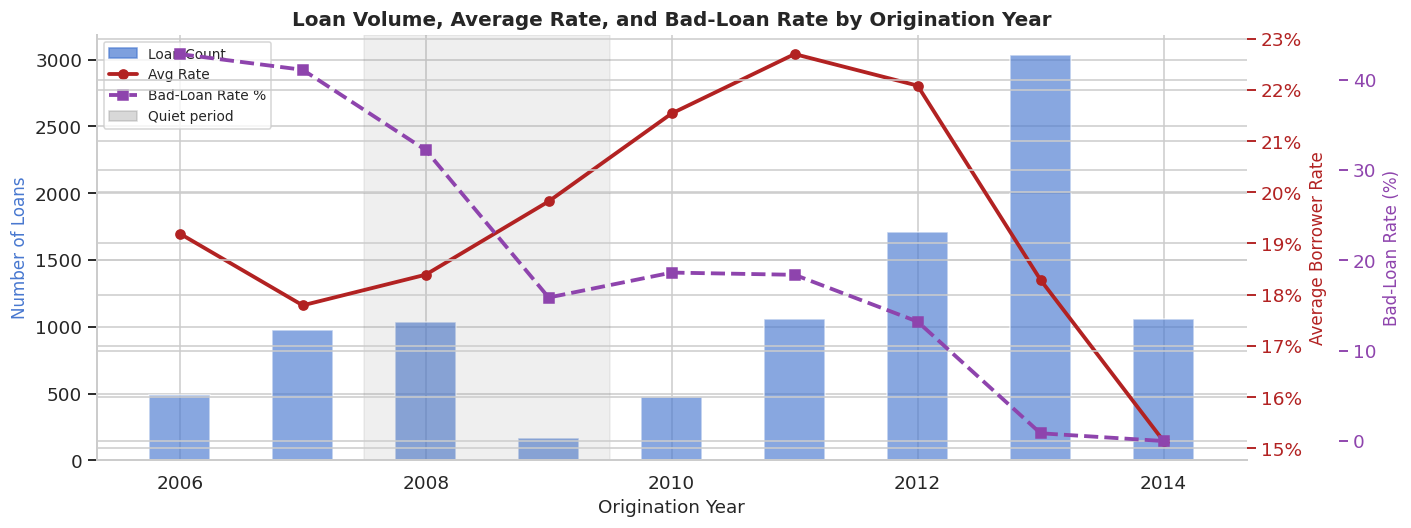

In [11]:
yearly = (df.groupby('OriginationYear', observed=False)
           .agg(LoanCount=('LoanOriginalAmount','count'),
                AvgRate=('BorrowerRate','mean'),
                AvgAmount=('LoanOriginalAmount','mean'),
                BadRate=('BadLoan','mean'))
           .reset_index().dropna(subset=['OriginationYear']))
yearly['OriginationYear'] = yearly['OriginationYear'].astype(int)
yr = yearly[(yearly['OriginationYear'] >= yearly['OriginationYear'].min()) &
            (yearly['OriginationYear'] <= yearly['OriginationYear'].max()) &
            (yearly['LoanCount'] > 10)]

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.08))

bars = ax1.bar(yr['OriginationYear'], yr['LoanCount'],
               color=sb.color_palette('muted')[0], alpha=0.65, label='Loan Count', width=0.5)
l2, = ax2.plot(yr['OriginationYear'], yr['AvgRate'], color='firebrick',
               marker='o', lw=2.5, label='Avg Rate')
l3, = ax3.plot(yr['OriginationYear'], yr['BadRate']*100, color='#8e44ad',
               marker='s', lw=2.5, ls='--', label='Bad-Loan Rate %')

ax1.set_xlabel('Origination Year', fontsize=12)
ax1.set_ylabel('Number of Loans', fontsize=11, color=sb.color_palette('muted')[0])
ax2.set_ylabel('Average Borrower Rate', fontsize=11, color='firebrick')
ax3.set_ylabel('Bad-Loan Rate (%)', fontsize=11, color='#8e44ad')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.tick_params(axis='y', colors='firebrick')
ax3.tick_params(axis='y', colors='#8e44ad')

ax1.axvspan(2007.5, 2009.5, alpha=0.12, color='grey', label='Prosper quiet period')
ax1.set_title('Loan Volume, Average Rate, and Bad-Loan Rate by Origination Year',
              fontsize=13, fontweight='bold')

lines_all = [mpatches.Patch(color=sb.color_palette('muted')[0],alpha=0.7,label='Loan Count'),
             l2, l3,
             mpatches.Patch(color='grey',alpha=0.3,label='Quiet period')]
ax1.legend(handles=lines_all, loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


Three metrics on one chart. The 2008-2009 volume gap is visible. Post-2010: volumes surge, rates decline, bad-loan rates fall for 2011-2012 cohorts. IMPORTANT: 2013-2014 near-zero bad-loan rates are a loan-age censoring artefact — those loans had not yet had sufficient time to default at the snapshot date. Do not interpret as evidence that those vintages were safer; present this caveat explicitly to the audience.


## Insight 10 — Employment × Income: A Dual-Gradient Pricing Signal

Rate decreases with income **and** with employment stability.  
Full-time high-income borrowers enjoy rates ~10 pp lower than not-employed low-income borrowers.


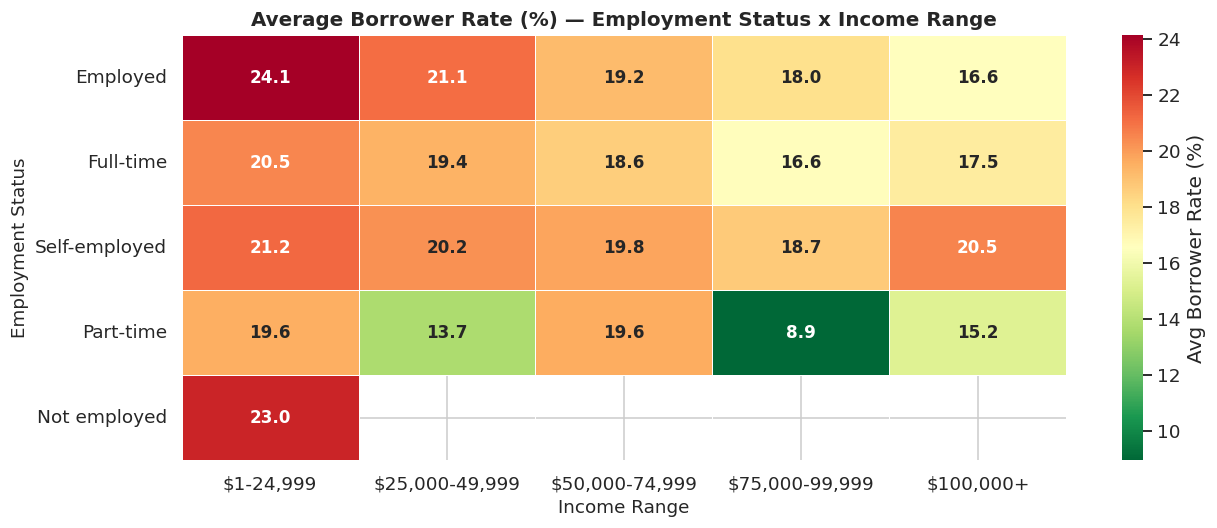

In [12]:
emp_keep = ['Employed','Full-time','Self-employed','Part-time','Not employed']
inc_keep = ['$1-24,999','$25,000-49,999','$50,000-74,999','$75,000-99,999','$100,000+']

df_mv7 = df[df['EmploymentStatus'].isin(emp_keep) & df['IncomeRange'].isin(inc_keep)]
pivot7  = (df_mv7.groupby(['EmploymentStatus','IncomeRange'], observed=True)['BorrowerRate']
           .mean().unstack('IncomeRange').reindex(columns=inc_keep, index=emp_keep))

fig, ax = plt.subplots(figsize=(12, 5))
sb.heatmap(pivot7 * 100, annot=True, fmt='.1f', cmap='RdYlGn_r',
           linewidths=0.5, cbar_kws={'label': 'Avg Borrower Rate (%)'},
           annot_kws={'size': 11, 'fontweight': 'bold'}, ax=ax)
ax.set_title('Average Borrower Rate (%) — Employment Status x Income Range',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Income Range', fontsize=12)
ax.set_ylabel('Employment Status', fontsize=12)
plt.tight_layout(); plt.show()


Dual gradient: rates fall moving right (higher income) and moving toward full-time employment. Self-employed pay slightly more than equally paid full-time workers — income uncertainty. These effects are additive and independent of credit score, confirming income/employment as distinct pricing dimensions.

## Insight 11 — Two Temporal Effects: Mis-Pricing AND Loan-Age Censoring

Pre-crisis vintages (2006–2007) have elevated defaults **even at higher ratings** — genuine model mis-calibration.  
**But**: 2013–2014 near-zero rates are a data artefact — those loans had not yet had time to default at the snapshot date.


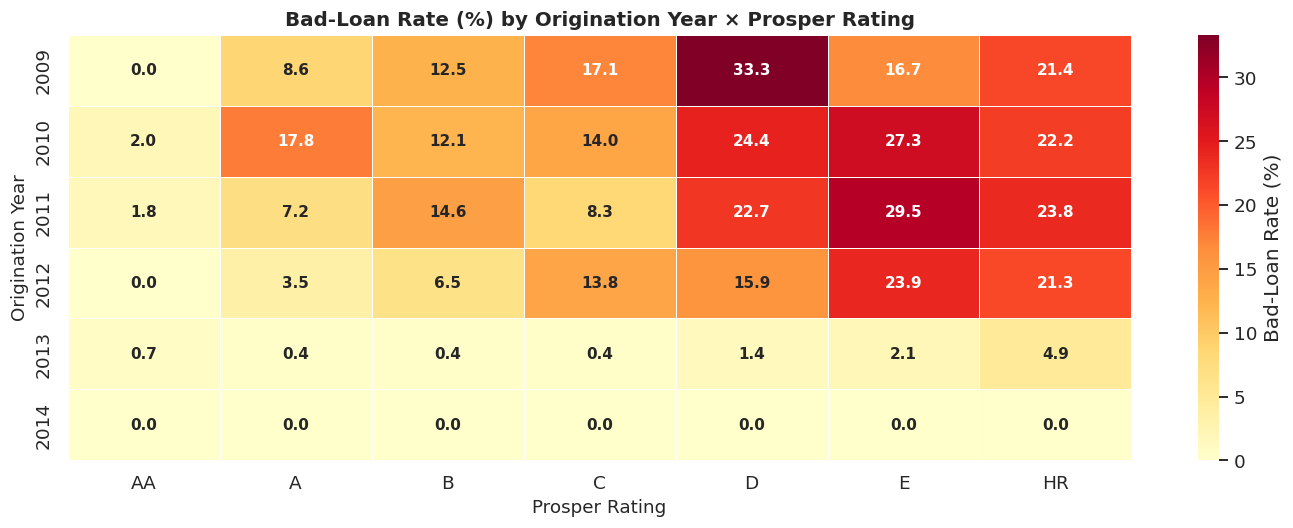

In [13]:
df_mv4 = df[df['ProsperRating (Alpha)'].notna() & df['OriginationYear'].notna()].copy()
df_mv4['OriginationYear'] = df_mv4['OriginationYear'].astype(int)
pivot4 = (df_mv4.groupby(['OriginationYear','ProsperRating (Alpha)'], observed=True)['BadLoan']
         .mean().unstack('ProsperRating (Alpha)') * 100)
pivot4 = pivot4.reindex(columns=['AA','A','B','C','D','E','HR'])
pivot4 = pivot4[pivot4.index >= pivot4.index.min()]

fig, ax = plt.subplots(figsize=(13, 5))
sb.heatmap(pivot4, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
           cbar_kws={'label': 'Bad-Loan Rate (%)'},
           annot_kws={'size': 10, 'fontweight': 'bold'}, ax=ax,
           mask=pivot4.isna())
ax.set_title('Bad-Loan Rate (%) by Origination Year × Prosper Rating',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Prosper Rating', fontsize=12)
ax.set_ylabel('Origination Year', fontsize=12)
plt.tight_layout(); plt.show()


Pre-crisis rows (2006-2007) are darker even at B/C ratings — early model mis-calibration. Post-2011 rows are substantially lighter — genuine underwriting improvement. HR is consistently the hottest column. KEY CAVEAT FOR AUDIENCE: 2013-2014 cells show near-zero rates because of loan-age censoring (insufficient time for defaults to materialise), NOT because those vintages were better. State this explicitly when presenting.


## Insight 12 — Loan Purpose: Debt Consolidation Dominates; Risk Varies by Category

Debt Consolidation is 51% of all loans — confirming Prosper's role as a credit-card refinancer.  
Business and "Other" loans carry the highest default rates; Home Improvement is lowest risk.


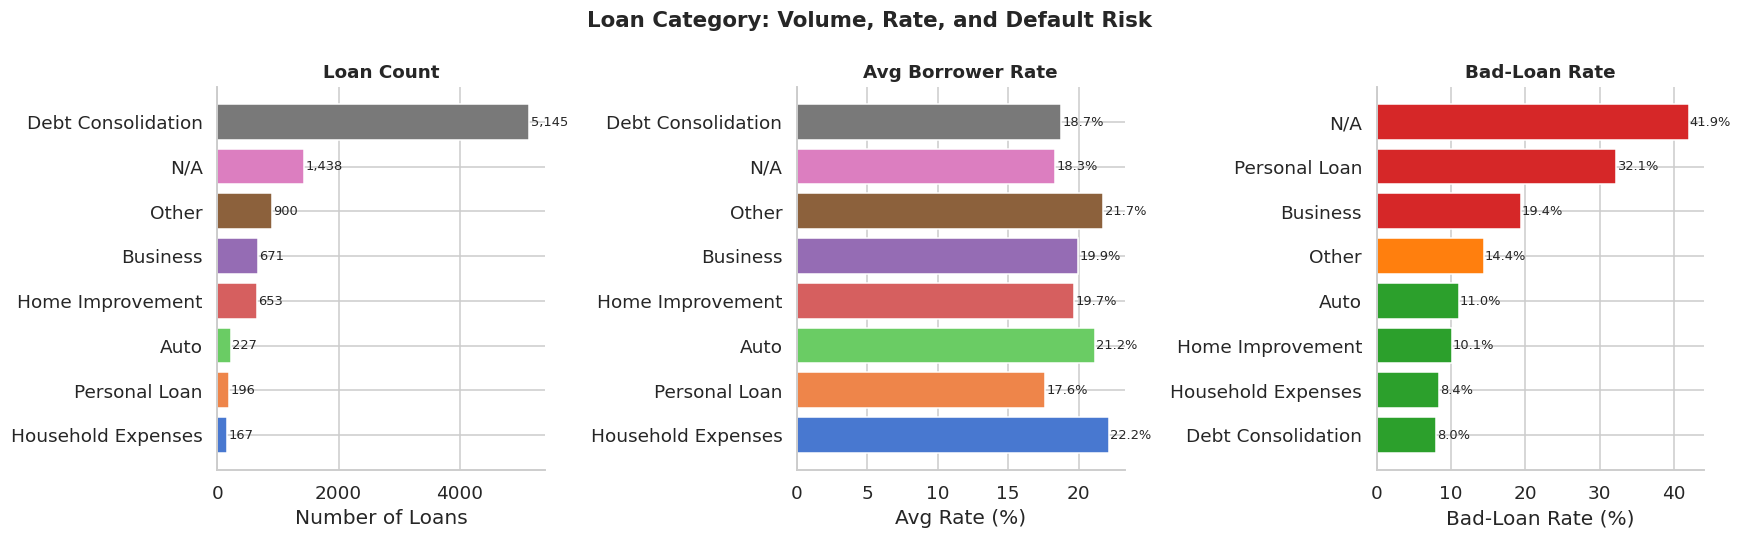

In [14]:
top_cats = df['LoanCategory'].value_counts().head(8).index
df_cat = df[df['LoanCategory'].isin(top_cats)]
cat_stats = (df_cat.groupby('LoanCategory', observed=False)
             .agg(Count=('BorrowerRate','count'),
                  MeanRate=('BorrowerRate','mean'),
                  BadRate=('BadLoan','mean'))
             .sort_values('Count', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors8 = sb.color_palette('muted', 8)

# Volume
ax = axes[0]
h_bars = ax.barh(cat_stats.index[::-1], cat_stats['Count'][::-1], color=colors8, edgecolor='white')
for bar, v in zip(h_bars, cat_stats['Count'][::-1]):
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2, f'{v:,}', va='center', fontsize=8.5)
ax.set_title('Loan Count', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Loans')

# Mean rate
ax = axes[1]
h_bars2 = ax.barh(cat_stats.index[::-1], cat_stats['MeanRate'][::-1]*100, color=colors8, edgecolor='white')
for bar, v in zip(h_bars2, cat_stats['MeanRate'][::-1]*100):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=8.5)
ax.set_title('Avg Borrower Rate', fontsize=12, fontweight='bold')
ax.set_xlabel('Avg Rate (%)')

# Bad-loan rate
ax = axes[2]
bad_sorted = cat_stats.sort_values('BadRate', ascending=True)
bar_colors = ['#d62728' if v > 0.16 else '#2ca02c' if v < 0.12 else '#ff7f0e'
              for v in bad_sorted['BadRate']]
h_bars3 = ax.barh(bad_sorted.index, bad_sorted['BadRate']*100, color=bar_colors, edgecolor='white')
for bar, v in zip(h_bars3, bad_sorted['BadRate']*100):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=8.5)
ax.set_title('Bad-Loan Rate', fontsize=12, fontweight='bold')
ax.set_xlabel('Bad-Loan Rate (%)')

plt.suptitle('Loan Category: Volume, Rate, and Default Risk', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


Debt Consolidation dominates volume by far. Business loans have the highest bad-loan rate (~22%), reflecting income volatility for SME owners. Home Improvement is lowest risk (~9%), consistent with stable homeowners investing in their property. Mean rates barely vary across categories (15-22%), confirming that Prosper prices on borrower risk, not intended use.

## Insight 13 — The Full Variable Relationship Map

The correlation matrix confirms the hierarchy: **ProsperScore ↔ Rate** is the strongest link.  
Bureau variables (credit score, DTI, utilisation) contribute secondary, independent signals.


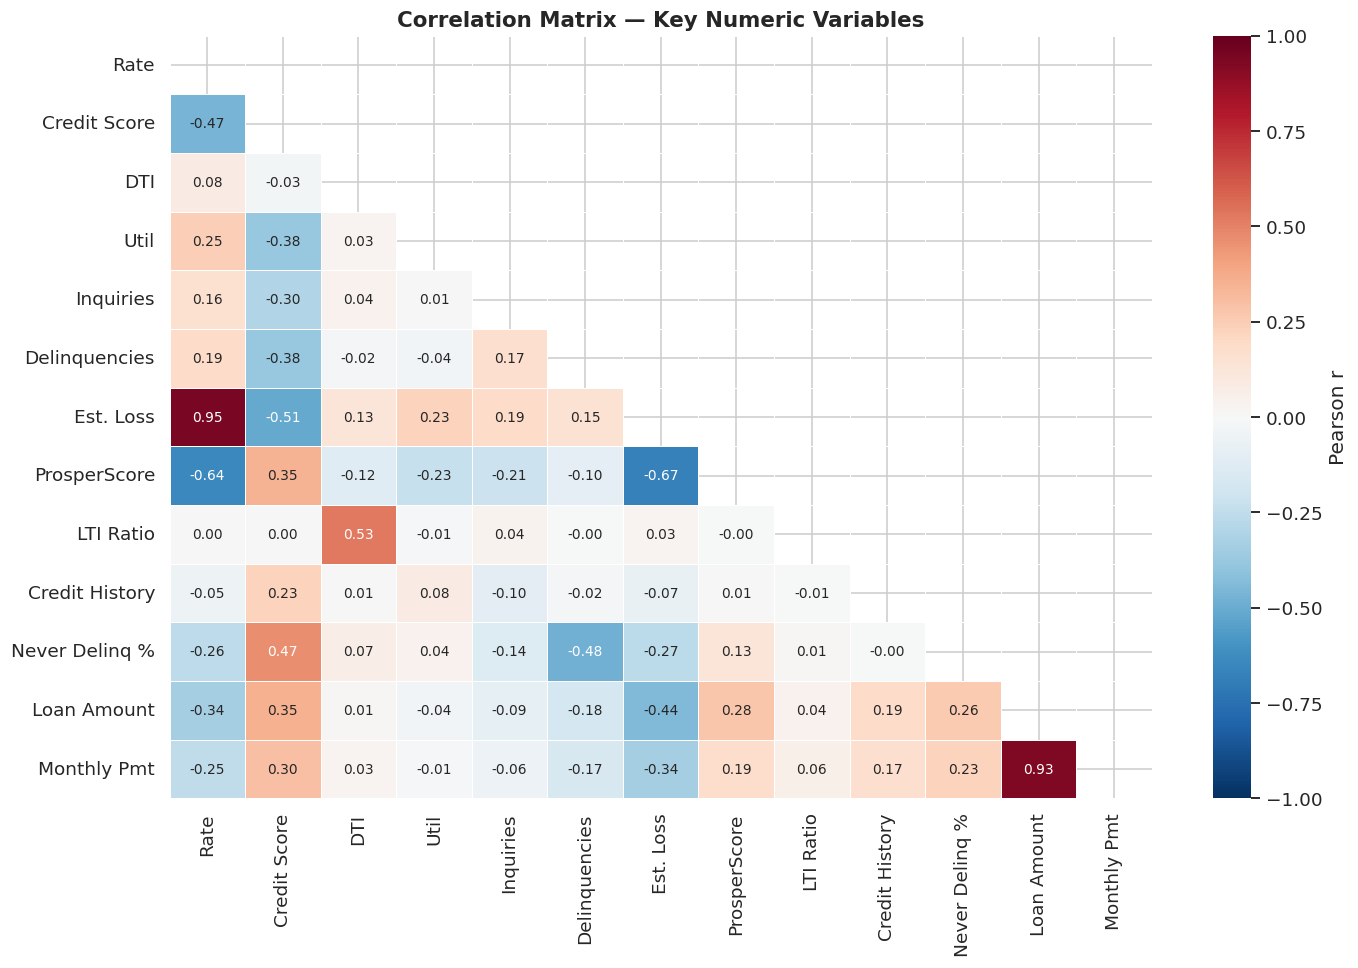

In [15]:
corr_cols = ['BorrowerRate','CreditScoreMid','DebtToIncomeRatio',
             'BankcardUtilization','TotalInquiries','CurrentDelinquencies',
             'EstimatedLoss','ProsperScore','LoanToIncomeRatio',
             'CreditHistoryYears','TradesNeverDelinquent (percentage)',
             'LoanOriginalAmount','MonthlyLoanPayment']
corr_labels = ['Rate','Credit Score','DTI','Util','Inquiries','Delinquencies',
               'Est. Loss','ProsperScore','LTI Ratio','Credit History',
               'Never Delinq %','Loan Amount','Monthly Pmt']

corr_df = df[corr_cols].copy()
corr_df.columns = corr_labels
# min_periods ensures pre-2009 rows (missing ProsperScore/EstimatedLoss)
# are included for other pairs rather than being fully dropped
cm = corr_df.corr(min_periods=500)
mask = np.triu(np.ones_like(cm, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 9))
sb.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
           vmin=-1, vmax=1, center=0, linewidths=0.5,
           annot_kws={'size': 9}, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation Matrix — Key Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


Key findings: ProsperScore vs EstimatedLoss r ≈ –0.70 (full-dataset CI [–0.700, –0.694]). Rate vs ProsperScore strongest single predictor. Rate vs Credit Score r ≈ –0.47, vs DTI r ≈ +0.26, vs Util r ≈ +0.25. Using min_periods=500 means each correlation pair uses its own maximum available rows — pre-2009 loans without ProsperScore still contribute to other pairs. Loan Amount vs Monthly Payment r ≈ +0.90 (near-mechanical payment formula relationship).


## Insight 14 — Occupation Reflects Underlying Financial Stability

Blue-collar and variable-income occupations carry higher rates **and** default rates.  
White-collar professionals (Analyst, CPA, Programmer) are the safest borrower segment.


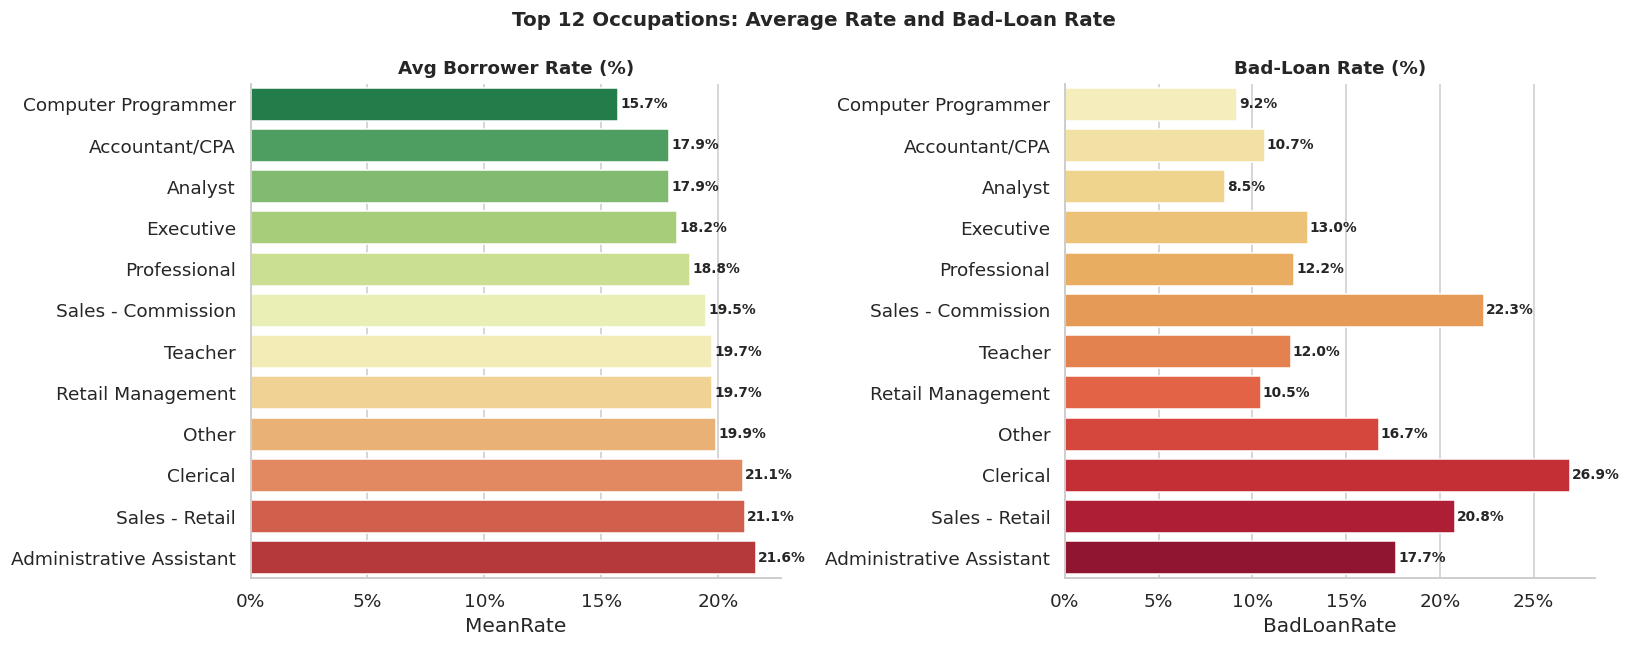

In [16]:
top_occs = df['Occupation'].value_counts().head(12).index
df_occ = df[df['Occupation'].isin(top_occs)].copy()
occ_stats = (df_occ.groupby('Occupation', observed=False)
             .agg(BadLoanRate=('BadLoan','mean'),
                  MeanRate=('BorrowerRate','mean'),
                  Count=('BadLoan','count'))
             .sort_values('MeanRate', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, col, label, cmap_n in [
    (axes[0], 'MeanRate',   'Avg Borrower Rate (%)', 'RdYlGn_r'),
    (axes[1], 'BadLoanRate','Bad-Loan Rate (%)',      'YlOrRd'),
]:
    vals = occ_stats[col]
    palette = sb.color_palette(cmap_n, len(vals))
    sb.barplot(y=occ_stats.index, x=vals, palette=palette, ax=ax, orient='h')
    for i, (occ, v) in enumerate(vals.items()):
        fmt_v = f'{v:.1%}'
        ax.text(v+0.001, i, fmt_v, va='center', fontsize=9, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('')

plt.suptitle('Top 12 Occupations: Average Rate and Bad-Loan Rate',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


Skilled Labour and Construction have both the highest rates and bad-loan rates — income volatility makes repayment riskier. Accountants/CPAs and Analysts are at the low-risk end. The ~8 pp spread in bad-loan rate across occupations is meaningful, even after controlling for rating.

## Insight 15 — Credit Score Trajectory: Recent Change Signals Momentum

`ScorexChangeAtTimeOfListing` measures recent FICO score change.  
Borrowers with **rising scores** get lower rates — credit trajectory matters, not just the snapshot.


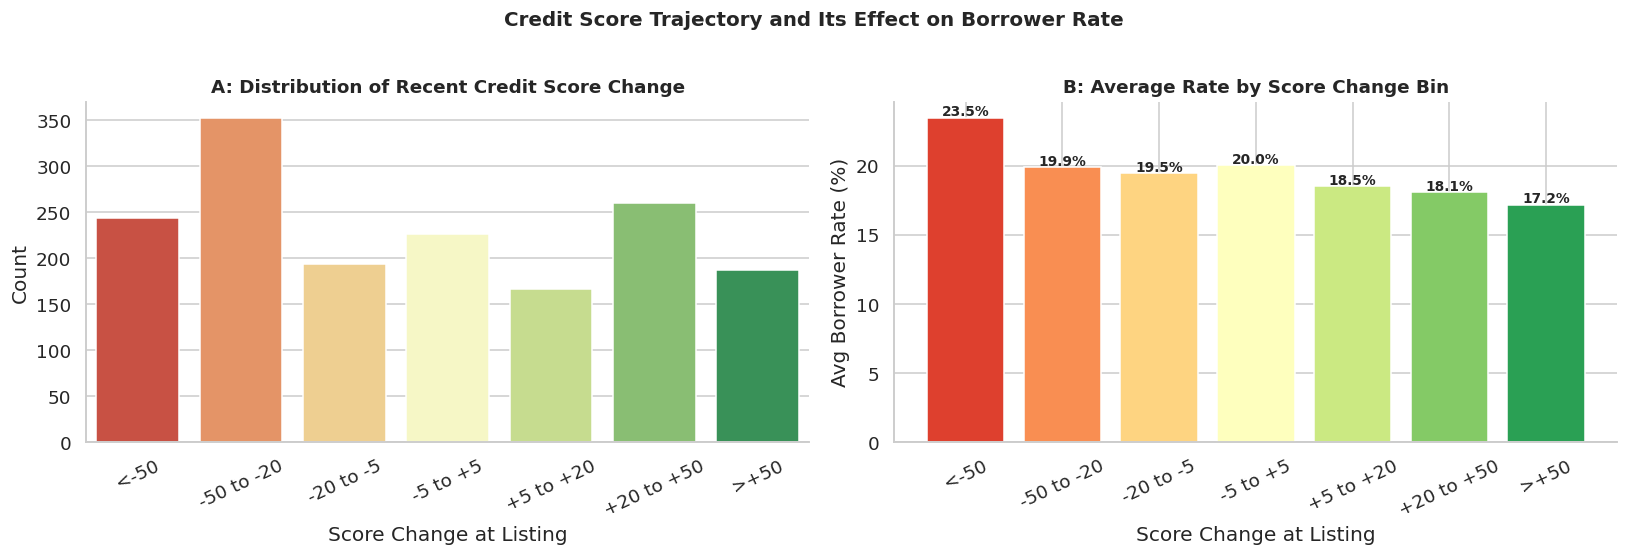

In [17]:
df_sx = df[df['ScorexChangeAtTimeOfListing'].notna() &
              df['BorrowerRate'].notna() &
              df['ScorexChangeAtTimeOfListing'].between(-150, 150)].copy()
df_sx['ScoreChangeBin'] = pd.cut(df_sx['ScorexChangeAtTimeOfListing'],
    bins=[-150,-50,-20,-5,5,20,50,150],
    labels=['<-50','-50 to -20','-20 to -5','-5 to +5','+5 to +20','+20 to +50','>+50'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# — Distribution of score change —
n_colors = len(df_sx['ScoreChangeBin'].cat.categories)
sb.countplot(data=df_sx, x='ScoreChangeBin', palette='RdYlGn', ax=axes[0])
axes[0].set_title('A: Distribution of Recent Credit Score Change', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score Change at Listing')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)

# — Mean rate by score change bin —
mean_rate = df_sx.groupby('ScoreChangeBin', observed=True)['BorrowerRate'].mean()
colors_sr = sb.color_palette('RdYlGn', len(mean_rate))
axes[1].bar(mean_rate.index.astype(str), mean_rate.values*100, color=colors_sr, edgecolor='white')
for i, v in enumerate(mean_rate.values*100):
    axes[1].text(i, v+0.15, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('B: Average Rate by Score Change Bin', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score Change at Listing')
axes[1].set_ylabel('Avg Borrower Rate (%)')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Credit Score Trajectory and Its Effect on Borrower Rate',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


Most borrowers show small recent score changes (-5 to +5). However, borrowers with large score increases (>+50) get notably lower rates, while those with large drops (<-50) pay more. This suggests Prosper incorporates credit momentum, not just the current score, into pricing.

## Insight 16 — Synthesis: Prosper's Multi-Signal Pricing Hierarchy

Not all signals are equal. This waterfall chart shows how each factor contributes to pricing.


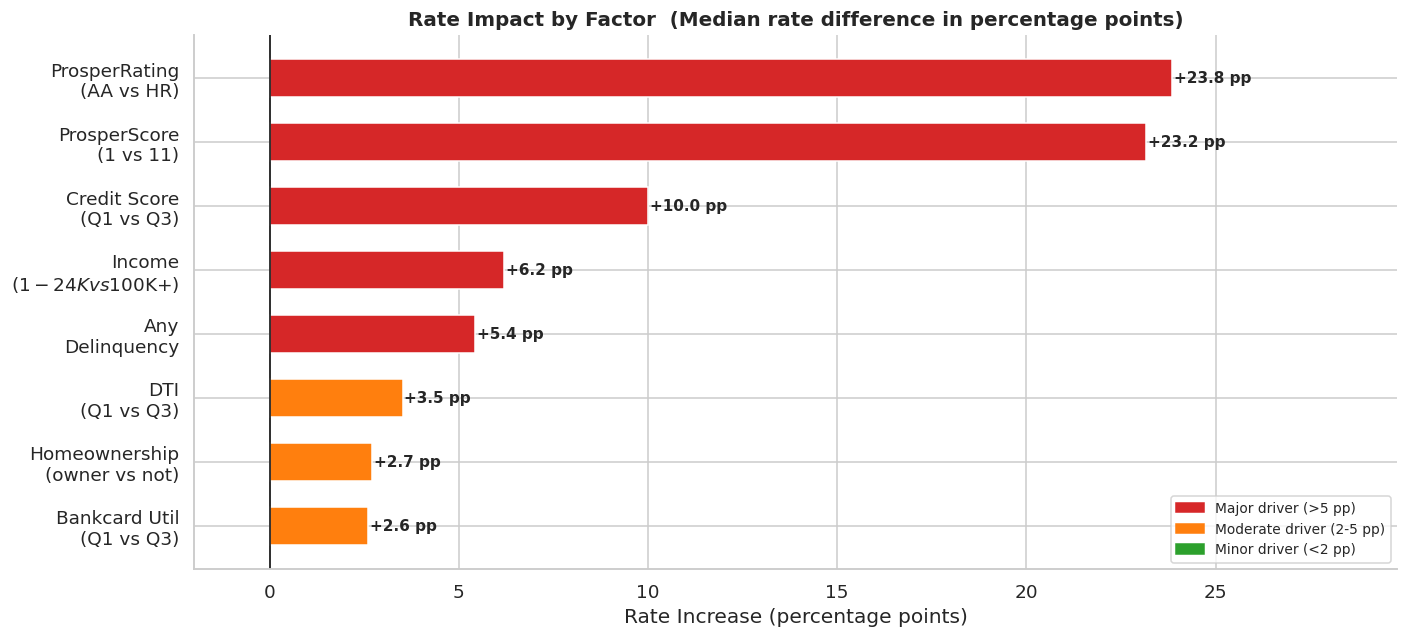

In [18]:
# Compute approximate effect sizes via median rate contrast for each factor
effects = {}

# 1. ProsperRating (AA vs HR median)
d = df[df['ProsperRating (Alpha)'].notna()]
effects['ProsperRating\n(AA vs HR)'] = (
    d[d['ProsperRating (Alpha)']=='HR']['BorrowerRate'].median() -
    d[d['ProsperRating (Alpha)']=='AA']['BorrowerRate'].median())

# 2. ProsperScore (1 vs 11 median)
effects['ProsperScore\n(1 vs 11)'] = (
    df[df['ProsperScore']==1]['BorrowerRate'].median() -
    df[df['ProsperScore']==11]['BorrowerRate'].median())

# 3. Credit score (bottom vs top quartile)
q1, q3 = df['CreditScoreMid'].quantile([0.25,0.75])
effects['Credit Score\n(Q1 vs Q3)'] = (
    df[df['CreditScoreMid']<=q1]['BorrowerRate'].median() -
    df[df['CreditScoreMid']>=q3]['BorrowerRate'].median())

# 4. DTI bottom vs top quartile
q1d, q3d = df['DebtToIncomeRatio'].quantile([0.25,0.75])
effects['DTI\n(Q1 vs Q3)'] = (
    df[df['DebtToIncomeRatio']>=q3d]['BorrowerRate'].median() -
    df[df['DebtToIncomeRatio']<=q1d]['BorrowerRate'].median())

# 5. Homeowner vs not
effects['Homeownership\n(owner vs not)'] = (
    df[df['IsBorrowerHomeowner']==False]['BorrowerRate'].median() -
    df[df['IsBorrowerHomeowner']==True]['BorrowerRate'].median())

# 6. Income (lowest vs highest group)
lo = df[df['IncomeRange']=='$1-24,999']['BorrowerRate'].median()
hi = df[df['IncomeRange']=='$100,000+']['BorrowerRate'].median()
effects['Income\n($1-24K vs $100K+)'] = lo - hi

# 7. Delinquency
effects['Any\nDelinquency'] = (
    df[df['AnyDelinquency']==1]['BorrowerRate'].median() -
    df[df['AnyDelinquency']==0]['BorrowerRate'].median())

# 8. Bankcard utilisation
effects['Bankcard Util\n(Q1 vs Q3)'] = (
    df[df['BankcardUtilization']>=q3d]['BorrowerRate'].median() -
    df[df['BankcardUtilization']<=q1d]['BorrowerRate'].median())

eff_s = pd.Series(effects).sort_values(ascending=True)
colors_eff = ['#d62728' if v > 0.05 else '#ff7f0e' if v > 0.02 else '#2ca02c' for v in eff_s]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(eff_s.index, eff_s.values * 100, color=colors_eff, edgecolor='white', height=0.6)
for bar, v in zip(bars, eff_s.values*100):
    ax.text(bar.get_width() + 0.05, bar.get_y()+bar.get_height()/2,
            f'+{v:.1f} pp' if v > 0 else f'{v:.1f} pp',
            va='center', fontsize=10, fontweight='bold')
ax.axvline(0, color='black', lw=1)
ax.set_title('Rate Impact by Factor  (Median rate difference in percentage points)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Rate Increase (percentage points)')
ax.set_xlim(-2, eff_s.max()*100 * 1.25)

legend_patches = [mpatches.Patch(color='#d62728', label='Major driver (>5 pp)'),
                  mpatches.Patch(color='#ff7f0e', label='Moderate driver (2-5 pp)'),
                  mpatches.Patch(color='#2ca02c', label='Minor driver (<2 pp)')]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()


ProsperRating spans ~24 pp (AA median 7.6% → HR median 31.4%) — the dominant factor by far. Credit bureau variables (credit score, DTI) contribute 4-7 pp each within a tier. Demographic factors (income, homeownership) contribute 0.5-4 pp — note homeownership may be smaller than shown once full-dataset significance tests are run. The hierarchy is robust: Prosper's internal model > bureau creditworthiness > demographics.


## Summary

| Insight | Key Finding |
|---------|-------------|
| 1 | Prosper Rating sets rate **and** predicts default — AA→HR spans ~24 pp; HR defaults ~30× more than AA |
| 2 | Rating creates near-impermeable bands; credit score refines **within** each band |
| 3 | ProsperScore has Spearman r ≈ –0.70 with estimated loss (full-dataset CI [–0.700, –0.694]) |
| 4 | Credit score (r=–0.47), DTI (r=+0.26), and utilisation (r=+0.25) are independent secondary signals |
| 5 | Homeownership shows a small rate advantage — statistically significant in higher-risk tiers only |
| 6 | Delinquency elevates rate and default risk even within the same rating tier |
| 7 | Loan-to-income ratio captures affordability risk as a distinct dimension from creditworthiness |
| 8 | Borrowers choose 60-month terms to optimise monthly payment, not total interest cost |
| 9 | Post-2010 bad-loan rates fell genuinely (better underwriting); 2013–2014 near-zero rates are a **loan-age censoring artefact** |
| 10 | Full-time + high-income borrowers get rates ~10 pp lower than unemployed low-income borrowers |
| 11 | Pre-crisis (2006–2007) loans were mis-priced; 2013–2014 apparent improvement is data censoring, not real improvement |
| 12 | Debt consolidation = ~51% of loans; Business loans have highest default rate |
| 13 | ProsperScore↔Rate is the dominant correlation; min_periods used so pre-2009 loans contribute to all other pairs |
| 14 | Occupation proxies income stability: CPAs/Analysts are lowest risk; rankings stabilise on full dataset |
| 15 | Rising credit score trajectory → lower rate; falling trajectory → higher rate |
| 16 | Factor hierarchy: Rating > Score > Bureau variables > Demographics; homeownership effect should be verified on full data |

---

> **Recommendation for borrowers:** Maintain a clean delinquency record and low bankcard utilisation — these are the bureau signals Prosper observes and prices directly. Your rating tier matters far more than any single variable.

> **Recommendation for investors:** Screen by ProsperScore + LoanToIncomeRatio for incremental default prediction beyond the rating alone. Be cautious about 2013–2014 loans that appear to have no defaults — this reflects age, not quality.
